In [1]:
import sys
sys.executable

'/home/alkhaldieid/miniforge3/envs/ai/bin/python3.9'

In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU found")


CUDA available: True
GPU name: NVIDIA GeForce RTX 2080


In [10]:
!ls ../data/Worksite-Safety-Monitoring-Dataset/

test  train  valid


In [9]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

img_size = 224
batch_size = 32

# Common transforms
transform = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.ToTensor(),  # converts to [0, 1] and channel-first
])

# Paths
data_root = '../data/Worksite-Safety-Monitoring-Dataset'

train_data = datasets.ImageFolder(root=f'{data_root}/train', transform=transform)
val_data   = datasets.ImageFolder(root=f'{data_root}/valid', transform=transform)
test_data  = datasets.ImageFolder(root=f'{data_root}/test',  transform=transform)

# DataLoaders
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False)

# Check class names
print("Classes:", train_data.classes)


Classes: ['safe', 'unsafe']


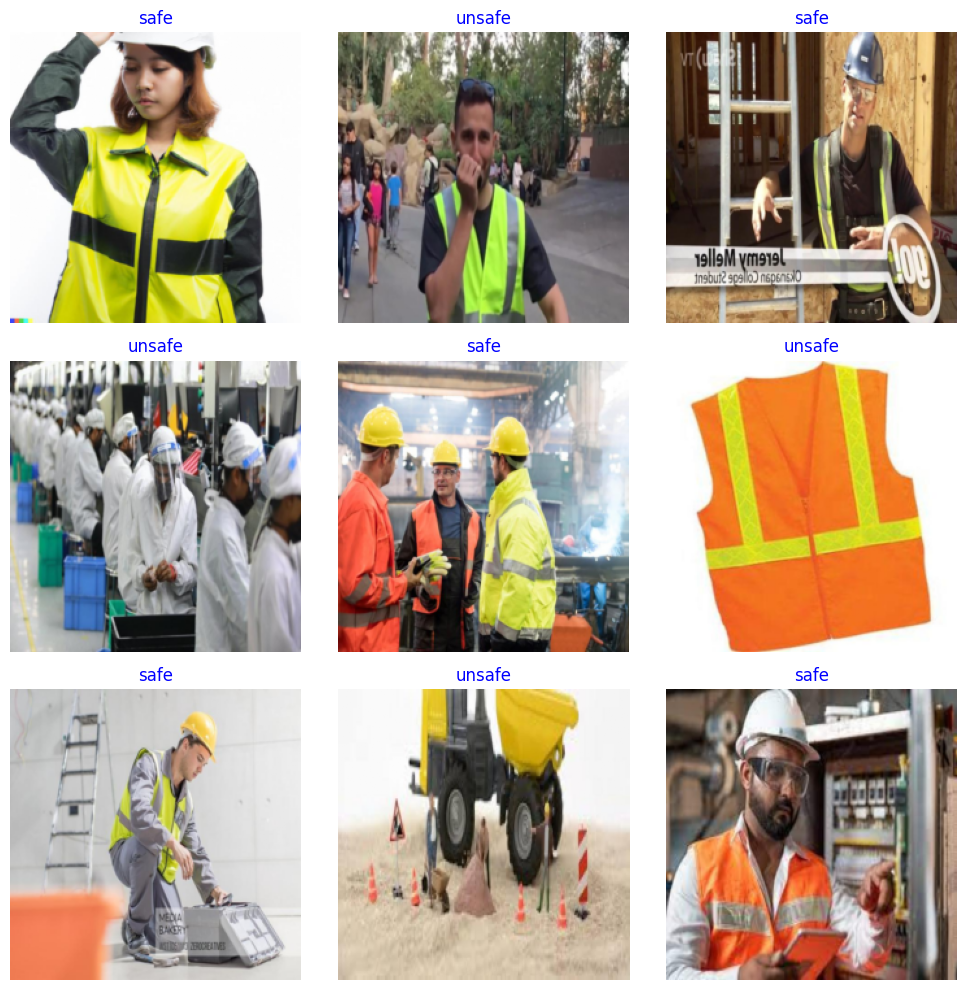

In [11]:
import matplotlib.pyplot as plt
import torchvision

def visualize_dataset(dataloader, class_names, num_images=9):
    plt.figure(figsize=(10, 10))
    images_shown = 0

    # Get one batch
    images, labels = next(iter(dataloader))

    for j in range(min(num_images, len(images))):
        img = images[j]
        label = labels[j]

        # Unnormalize if necessary — here ToTensor already gives [0,1]
        img = img.permute(1, 2, 0).numpy()  # CHW ➜ HWC

        ax = plt.subplot(3, 3, j + 1)
        plt.imshow(img)
        plt.title(class_names[label], fontsize=12, color='blue')
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Call with train_loader
visualize_dataset(train_loader, train_data.classes, num_images=9)


In [12]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models

# Data augmentation
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(10),
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=0, scale=(0.9, 1.1)),  # Zoom approximation
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ResNet50 expects these
                         std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Load pretrained ResNet50
class ResNet50Classifier(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.resnet = models.resnet50(pretrained=pretrained)

        # Remove original FC layer
        self.resnet.fc = nn.Identity()

        # Custom classifier
        self.classifier = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.5),
            nn.Linear(256, 1),
            nn.Sigmoid()  # For binary classification
        )

    def forward(self, x):
        x = self.resnet(x)
        x = self.classifier(x)
        return x

# Instantiate and move to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet50Classifier().to(device)
print(model)


/home/alkhaldieid/miniforge3/envs/ai/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/alkhaldieid/miniforge3/envs/ai/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet50Classifier(
  (resnet): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(


In [13]:
for param in model.resnet.parameters():
    param.requires_grad = False

    
for name, param in model.named_parameters():
    print(f"{name}: {'trainable' if param.requires_grad else 'frozen'}")


resnet.conv1.weight: frozen
resnet.bn1.weight: frozen
resnet.bn1.bias: frozen
resnet.layer1.0.conv1.weight: frozen
resnet.layer1.0.bn1.weight: frozen
resnet.layer1.0.bn1.bias: frozen
resnet.layer1.0.conv2.weight: frozen
resnet.layer1.0.bn2.weight: frozen
resnet.layer1.0.bn2.bias: frozen
resnet.layer1.0.conv3.weight: frozen
resnet.layer1.0.bn3.weight: frozen
resnet.layer1.0.bn3.bias: frozen
resnet.layer1.0.downsample.0.weight: frozen
resnet.layer1.0.downsample.1.weight: frozen
resnet.layer1.0.downsample.1.bias: frozen
resnet.layer1.1.conv1.weight: frozen
resnet.layer1.1.bn1.weight: frozen
resnet.layer1.1.bn1.bias: frozen
resnet.layer1.1.conv2.weight: frozen
resnet.layer1.1.bn2.weight: frozen
resnet.layer1.1.bn2.bias: frozen
resnet.layer1.1.conv3.weight: frozen
resnet.layer1.1.bn3.weight: frozen
resnet.layer1.1.bn3.bias: frozen
resnet.layer1.2.conv1.weight: frozen
resnet.layer1.2.bn1.weight: frozen
resnet.layer1.2.bn1.bias: frozen
resnet.layer1.2.conv2.weight: frozen
resnet.layer1.2.bn2.

In [14]:
import torch.optim as optim
import torch.nn as nn

# Binary classification setup
criterion = nn.BCELoss()  # since model ends in Sigmoid
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [15]:
import torch

def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=50):
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        running_acc = 0.0
        total = 0

        for inputs, labels in train_loader:
            inputs = inputs.to(device)
            labels = labels.float().unsqueeze(1).to(device)  # BCE expects shape (batch, 1)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            preds = (outputs > 0.5).float()
            running_loss += loss.item() * inputs.size(0)
            running_acc += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = running_acc / total

        # Validation
        model.eval()
        val_loss = 0.0
        val_acc = 0.0
        val_total = 0

        with torch.no_grad():
            for val_inputs, val_labels in val_loader:
                val_inputs = val_inputs.to(device)
                val_labels = val_labels.float().unsqueeze(1).to(device)

                val_outputs = model(val_inputs)
                loss = criterion(val_outputs, val_labels)
                preds = (val_outputs > 0.5).float()

                val_loss += loss.item() * val_inputs.size(0)
                val_acc += (preds == val_labels).sum().item()
                val_total += val_labels.size(0)

        val_loss /= val_total
        val_acc /= val_total

        print(f"Epoch {epoch+1}/{epochs} — "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f} — "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

        model.train()

# Example call:
train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=50)


Epoch 1/50 — Train Loss: 0.6468, Train Acc: 0.6358 — Val Loss: 0.5214, Val Acc: 0.7400
Epoch 2/50 — Train Loss: 0.5041, Train Acc: 0.7549 — Val Loss: 0.5070, Val Acc: 0.7300
Epoch 3/50 — Train Loss: 0.4569, Train Acc: 0.7877 — Val Loss: 0.4681, Val Acc: 0.7750
Epoch 4/50 — Train Loss: 0.4041, Train Acc: 0.8173 — Val Loss: 0.4656, Val Acc: 0.8000
Epoch 5/50 — Train Loss: 0.3878, Train Acc: 0.8278 — Val Loss: 0.4681, Val Acc: 0.7950
Epoch 6/50 — Train Loss: 0.3709, Train Acc: 0.8290 — Val Loss: 0.4894, Val Acc: 0.7800
Epoch 7/50 — Train Loss: 0.3472, Train Acc: 0.8488 — Val Loss: 0.4823, Val Acc: 0.7700
Epoch 8/50 — Train Loss: 0.3379, Train Acc: 0.8605 — Val Loss: 0.4701, Val Acc: 0.7950
Epoch 9/50 — Train Loss: 0.3206, Train Acc: 0.8543 — Val Loss: 0.4753, Val Acc: 0.8000
Epoch 10/50 — Train Loss: 0.3047, Train Acc: 0.8747 — Val Loss: 0.4652, Val Acc: 0.8050
Epoch 11/50 — Train Loss: 0.3025, Train Acc: 0.8630 — Val Loss: 0.5350, Val Acc: 0.7500
Epoch 12/50 — Train Loss: 0.2797, Train A